In [1]:
import pandas as pd
import numpy as np
import deepchem as dc

# ==============================
# 1. Load Full Dataset
# ==============================
prom_df = pd.read_csv(r"D:\gsoc26\deepchem\deepchem\feat\dataset\promoter.csv")
nonprom_df = pd.read_csv(r"D:\gsoc26\deepchem\deepchem\feat\dataset\non_promoter.csv")

prom_seqs = prom_df.iloc[:, 0].str.upper().values
nonprom_seqs = nonprom_df.iloc[:, 0].str.upper().values

prom_labels = np.ones(len(prom_seqs))
nonprom_labels = np.zeros(len(nonprom_seqs))

sequences = np.concatenate([prom_seqs, nonprom_seqs])
labels = np.concatenate([prom_labels, nonprom_labels])

# ==============================
# 2. Select 100 from each class
# ==============================
prom_idx = np.where(labels == 1)[0][:100]
nonprom_idx = np.where(labels == 0)[0][:100]

small_idx = np.concatenate([prom_idx, nonprom_idx])

small_sequences = sequences[small_idx]
small_labels = labels[small_idx]

# ==============================
# 3. Build DeepChem Dataset
# ==============================
small_dataset = dc.data.NumpyDataset(
    X=small_sequences.reshape(-1, 1),
    y=small_labels.reshape(-1, 1)
)

print("Small dataset size:", len(small_dataset))

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
d:\gsoc26\playground\dc_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, mi

Small dataset size: 200


In [7]:
import torch
import gc
import numpy as np
from deepchem.models.torch_models.dnabert import DNABERT2

# ==============================
# 4. Train / Test Split
# ==============================
splitter = dc.splits.RandomSplitter()
train_dataset, _, test_dataset = splitter.train_valid_test_split(
    small_dataset,
    frac_train=0.8,
    frac_valid=0.0,
    frac_test=0.2,
    seed=42
)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

# ==============================
# 5. Build Model
# ==============================
model = DNABERT2(
    task="classification",
    n_tasks=1,
    learning_rate=5e-4,
    batch_size=4,
)

# Freeze encoder — train head only
# Freeze entire bert
for param in model.model.bert.parameters():
    param.requires_grad = False

# Then unfreeze just the pooler
for param in model.model.bert.pooler.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

# ==============================
# 6. Train
# ==============================
losses = []

print("\nTraining...")
for epoch in range(10):
    loss = model.fit(train_dataset, nb_epoch=1)
    losses.append(float(loss))

    with torch.inference_mode():
        preds_raw = np.asarray(model.predict(train_dataset))

    if preds_raw.ndim == 3:
        preds_raw = preds_raw[:, 0, :]

    preds = np.argmax(preds_raw, axis=1)
    dist = np.bincount(preds, minlength=2)

    print(f"Epoch {epoch+1:02d} | Loss {loss:.4f} | Pred dist {dist}")

    gc.collect()
    torch.cuda.empty_cache()

Train: 160 | Test: 40


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at zhihan1996/DNABERT-2-117M and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable params: 592,130 / 117,070,082

Training...
Epoch 01 | Loss 0.6089 | Pred dist [62 98]
Epoch 02 | Loss 0.4637 | Pred dist [86 74]
Epoch 03 | Loss 0.3776 | Pred dist [88 72]
Epoch 04 | Loss 0.4084 | Pred dist [73 87]
Epoch 05 | Loss 0.4024 | Pred dist [82 78]
Epoch 06 | Loss 0.4045 | Pred dist [91 69]
Epoch 07 | Loss 0.3172 | Pred dist [103  57]
Epoch 08 | Loss 0.3003 | Pred dist [90 70]
Epoch 09 | Loss 0.2900 | Pred dist [93 67]
Epoch 10 | Loss 0.2708 | Pred dist [85 75]


Test Accuracy: 87.5%
              precision    recall  f1-score   support

Non-promoter       0.95      0.82      0.88        22
    Promoter       0.81      0.94      0.87        18

    accuracy                           0.88        40
   macro avg       0.88      0.88      0.87        40
weighted avg       0.89      0.88      0.88        40



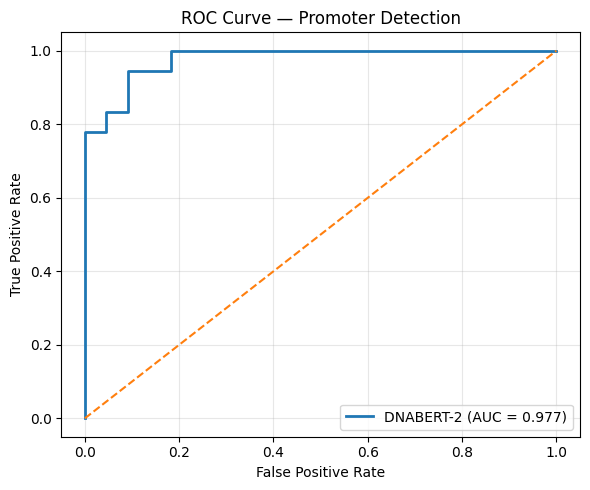

ROC AUC: 0.977


In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# ==============================
# Evaluate on test set
# ==============================
with torch.inference_mode():
    preds_raw = np.asarray(model.predict(test_dataset))

if preds_raw.ndim == 3:
    preds_raw = preds_raw[:, 0, :]

true_labels = np.asarray(test_dataset.y).reshape(-1).astype(int)
probs = preds_raw[:, 1]
preds = np.argmax(preds_raw, axis=1)

accuracy = accuracy_score(true_labels, preds)
print(f"Test Accuracy: {accuracy:.1%}")
print(classification_report(
    true_labels, preds,
    target_names=["Non-promoter", "Promoter"],
    zero_division=0
))

fpr, tpr, _ = roc_curve(true_labels, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"DNABERT-2 (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate") 
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Promoter Detection")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc:.3f}")